# LCS Evaluation and Full Model Comparison (Tasks 5 and 6)

## Purpose

Notebooks 04 and 07 developed the original and improved eLCS systems and
reported their results using metrics calculated directly with scikit-learn.
This notebook re-evaluates all three LCS configurations through
`src/evaluation.py`, the shared evaluation module, and then assembles the
complete Task 6 comparison.

Running the LCS models through the shared module serves three purposes:

1. **Identical metrics.** The LCS and conventional models are scored by the
   same code on the same held-out records, so the comparison is exact rather
   than approximate. This also adds ROC-AUC and PR-AUC, which were not
   reported in notebooks 04 and 07.
2. **Saved predictions.** The predictions are written to `results/predictions/`
   in the same format as the conventional models, which allows McNemar's test
   between the LCS and conventional models without refitting anything.
3. **The missing comparison row.** Task 6 requires the original LCS to be
   evaluated on the preprocessed dataset as well as on the raw dataset. That
   configuration is run here.

## Models evaluated

| Model | Training data | Configuration |
|---|---|---|
| Original eLCS (raw) | Full training split, 202,944 rows | eLCS defaults |
| Original eLCS (preprocessed) | Balanced training set, 56,554 rows | eLCS defaults |
| Improved eLCS | Balanced training set, 56,554 rows | Tuned in notebook 07 |

The improved configuration is the one selected by the validation-set tuning in
notebook 07: a population size of 2,000, a specificity probability of 0.10, and
explicit attribute typing so that the seven ordinal and continuous features are
represented as numerical ranges rather than discrete categories.

## Why the LCS models are not cross-validated

The conventional models in notebook 06 were evaluated with both a held-out test
set and 10-fold cross-validation. The LCS models are evaluated on the held-out
test set only.

The reason is runtime. A single improved-eLCS run in notebook 07 took roughly
74 seconds to train but 946 seconds to predict, because prediction requires
every test record to be matched against the full rule population. Ten-fold
cross-validation of three LCS configurations would therefore take
approximately eight hours, which is not practical for the available hardware.

This does not weaken the comparison. The held-out test set contains 50,736
records, and McNemar's test on those records has substantially more
statistical power than a ten-fold Wilcoxon test, which is limited to ten paired
observations. The cross-validation results from notebook 06 remain available
to show the stability of the conventional models.

## 1. Setup

In [1]:
import sys
import time
from pathlib import Path

sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skeLCS import eLCS

from src.evaluation import (
    RANDOM_STATE,
    evaluate_on_test,
    get_train_test_split,
    load_all_metrics,
    load_cleaned_data,
    load_predictions,
    pairwise_mcnemar,
    results_table,
    save_predictions,
)

sns.set_theme(style="whitegrid")
results_dir = Path("../results")

print("Python version:", sys.version.split()[0])
print("Shared random_state:", RANDOM_STATE)

Python version: 3.9.6
Shared random_state: 42


## 2. Data

Two training sets are needed: the full training split for the raw baseline, and
the balanced training set produced in notebook 05 for the preprocessed and
improved configurations. Both are evaluated on the same held-out test set.

In [2]:
# Full training split, used for the raw baseline
df = load_cleaned_data()
X_train_full, X_test, y_train_full, y_test = get_train_test_split(df)

# Balanced training set from notebook 05, used for the other two models
elcs_dir = Path("../data/processed/elcs")
balanced = pd.read_csv(elcs_dir / "diabetes_elcs_training_balanced.csv")

X_train_balanced = balanced.drop(columns=["Diabetes_binary"])
y_train_balanced = balanced["Diabetes_binary"].astype(int)

print("Full training set:    ", X_train_full.shape)
print("Balanced training set:", X_train_balanced.shape)
print("Held-out test set:    ", X_test.shape)

print("\nBalanced training class counts:")
print(y_train_balanced.value_counts().sort_index())

Full training set:     (202944, 21)
Balanced training set: (56554, 21)
Held-out test set:     (50736, 21)

Balanced training class counts:
Diabetes_binary
0    28277
1    28277
Name: count, dtype: int64


### Consistency checks

Two conditions must hold for the comparison to be valid. The feature columns
must be in the same order in both training sets and the test set, because eLCS
receives NumPy arrays and therefore identifies attributes by position rather
than by name. The test set must also be identical to the one used by the
conventional models, which is verified against the saved predictions.

In [3]:
assert list(X_train_full.columns) == list(X_test.columns), "Column order differs"
assert list(X_train_balanced.columns) == list(X_test.columns), "Column order differs"
print("Feature order consistent across all datasets")

saved_predictions, saved_y_test = load_predictions()

assert len(saved_y_test) == len(y_test), "Test set size differs from notebook 06"
assert np.array_equal(saved_y_test, np.asarray(y_test).astype(int)), (
    "Test labels differ from notebook 06 - the splits are not the same"
)

print("Test set matches notebook 06:", len(saved_y_test), "records")
print("Conventional models already saved:", len(saved_predictions))

Feature order consistent across all datasets
Test set matches notebook 06: 50736 records
Conventional models already saved: 9


## 3. Attribute configuration

By default, eLCS decides whether an attribute is discrete or continuous by
counting its distinct values, using `discrete_attribute_limit=10`. That
heuristic misclassifies this dataset: BMI, MentHlth and PhysHlth have many
distinct values and are correctly treated as continuous, but GenHlth (5
values), Age (13), Education (6) and Income (8) fall below the threshold and
are treated as unordered categories, which discards their ordering.

The improved system sets `discrete_attribute_limit="c"` and passes
`specified_attributes` explicitly, so that all seven ordered features are
represented as numerical ranges. This allows eLCS to form interval conditions
such as `GenHlth in [4, 5]` rather than separate categorical matches, which
produces more general and more interpretable rules.

In [4]:
range_based_features = [
    "BMI", "GenHlth", "MentHlth", "PhysHlth", "Age", "Education", "Income",
]

specified_attributes = np.array(
    [X_test.columns.get_loc(column) for column in range_based_features],
    dtype=int,
)

discrete_features = [
    column for column in X_test.columns if column not in range_based_features
]

print("Range-based attributes:", len(range_based_features))
for column in range_based_features:
    print(f"  {X_test.columns.get_loc(column):>2} -> {column}")

print("\nDiscrete attributes:", len(discrete_features))

Range-based attributes: 7
   3 -> BMI
  13 -> GenHlth
  14 -> MentHlth
  15 -> PhysHlth
  18 -> Age
  19 -> Education
  20 -> Income

Discrete attributes: 14


## 4. Run the three LCS configurations

Each model is fitted and evaluated through `evaluate_on_test()`, which returns
the full metric set and the predictions.

This cell is the slow part of the notebook. Prediction requires every test
record to be matched against the entire rule population, so expect roughly
20 to 40 minutes in total, with the improved model taking the longest because
it has the largest population.

In [5]:
lcs_models = {
    "Original eLCS (raw)": {
        "model": eLCS(random_state=RANDOM_STATE),
        "X_train": X_train_full,
        "y_train": y_train_full,
    },
    "Original eLCS (preprocessed)": {
        "model": eLCS(random_state=RANDOM_STATE),
        "X_train": X_train_balanced,
        "y_train": y_train_balanced,
    },
    "Improved eLCS": {
        "model": eLCS(
            learning_iterations=10000,
            N=2000,
            p_spec=0.10,
            discrete_attribute_limit="c",
            specified_attributes=specified_attributes,
            random_state=RANDOM_STATE,
        ),
        "X_train": X_train_balanced,
        "y_train": y_train_balanced,
    },
}

lcs_results = []
lcs_predictions = {}
fitted_models = {}

overall_start = time.perf_counter()

for name, setup in lcs_models.items():
    print(f"\nRunning {name} ...")
    print(f"  training records: {len(setup['X_train']):,}")

    metrics, y_pred = evaluate_on_test(
        setup["model"], name,
        setup["X_train"], setup["y_train"],
        X_test, y_test,
        as_numpy=True,
    )

    lcs_results.append(metrics)
    lcs_predictions[name] = y_pred
    fitted_models[name] = setup["model"]

    print(
        f"  balanced accuracy={metrics['balanced_accuracy']:.4f}  "
        f"recall={metrics['recall']:.4f}  "
        f"PR-AUC={metrics['pr_auc']:.4f}"
    )
    print(
        f"  fit={metrics['fit_time_s']:.1f}s  "
        f"predict={metrics['predict_time_s']:.1f}s  "
        f"unclassified={metrics['unclassified']}"
    )

print(f"\nTotal runtime: {(time.perf_counter() - overall_start) / 60:.1f} minutes")


Running Original eLCS (raw) ...
  training records: 202,944
  balanced accuracy=0.5000  recall=0.0000  PR-AUC=0.2495
  fit=13.7s  predict=103.0s  unclassified=0

Running Original eLCS (preprocessed) ...
  training records: 56,554
  balanced accuracy=0.7302  recall=0.7640  PR-AUC=0.3578
  fit=9.9s  predict=97.3s  unclassified=0

Running Improved eLCS ...
  training records: 56,554
  balanced accuracy=0.7309  recall=0.7621  PR-AUC=0.3635
  fit=12.7s  predict=224.7s  unclassified=0

Total runtime: 7.7 minutes


In [6]:
lcs_table = results_table(lcs_results)

display(
    lcs_table[[
        "accuracy", "balanced_accuracy", "precision",
        "recall", "f1", "roc_auc", "pr_auc", "unclassified",
    ]].round(4)
)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc,unclassified
model,,,,,,,,
Original eLCS (raw),0.8606,0.5000,0.0000,0.0000,0.0000,0.6911,0.2495,0
Original eLCS (preprocessed),0.7057,0.7302,0.2894,0.7640,0.4198,0.7982,0.3578,0
Improved eLCS,0.7085,0.7309,0.2913,0.7621,0.4215,0.8008,0.3635,0


### Effect of each change

Comparing the three configurations separates the contribution of the
preprocessing from the contribution of the LCS changes themselves, which is
what Task 4 requires the improved system to demonstrate.

In [7]:
baseline_score = lcs_table.loc["Original eLCS (raw)", "balanced_accuracy"]
preprocessed_score = lcs_table.loc["Original eLCS (preprocessed)", "balanced_accuracy"]
improved_score = lcs_table.loc["Improved eLCS", "balanced_accuracy"]

contributions = pd.DataFrame([
    {
        "Change": "Balanced training data only",
        "From": baseline_score,
        "To": preprocessed_score,
        "Gain": preprocessed_score - baseline_score,
    },
    {
        "Change": "Attribute typing and tuning",
        "From": preprocessed_score,
        "To": improved_score,
        "Gain": improved_score - preprocessed_score,
    },
    {
        "Change": "Total improvement",
        "From": baseline_score,
        "To": improved_score,
        "Gain": improved_score - baseline_score,
    },
])

print("Contribution to balanced accuracy\n")
print(contributions.round(4).to_string(index=False))

Contribution to balanced accuracy

                     Change   From     To   Gain
Balanced training data only 0.5000 0.7302 0.2302
Attribute typing and tuning 0.7302 0.7309 0.0008
          Total improvement 0.5000 0.7309 0.2310


In [8]:
# Save LCS results in the shared format
lcs_table.to_csv(results_dir / "lcs_test_metrics.csv")
save_predictions(lcs_predictions, y_test, results_dir=results_dir)

print("Saved lcs_test_metrics.csv and predictions for:")
for name in lcs_predictions:
    print(" ", name)

Saved lcs_test_metrics.csv and predictions for:
  Original eLCS (raw)
  Original eLCS (preprocessed)
  Improved eLCS


## 5. Full Task 6 comparison

The comparison required by Task 6 combines the LCS results with the
conventional models from notebook 06. All twelve models were trained and
evaluated on the same split, scored by the same code, and are therefore
directly comparable.

In [9]:
comparison = load_all_metrics(results_dir=results_dir)

comparison = comparison[[
    "accuracy", "balanced_accuracy", "precision", "recall",
    "f1", "specificity", "roc_auc", "pr_auc",
]].sort_values("balanced_accuracy", ascending=False)

display(comparison.round(4))

,accuracy,balanced_accuracy,precision,recall,f1,specificity,roc_auc,pr_auc
model,,,,,,,,
Random Forest (B),0.7184,0.7486,0.3038,0.7905,0.4389,0.7068,0.8229,0.4146
Logistic Regression (B),0.7317,0.7447,0.3112,0.7628,0.4421,0.7267,0.8195,0.3924
Logistic Regression (A),0.7316,0.7439,0.3108,0.7611,0.4414,0.7268,0.8196,0.3926
Logistic Regression (C),0.7320,0.7350,0.3078,0.7390,0.4346,0.7309,0.8066,0.3733
Improved eLCS,0.7085,0.7309,0.2913,0.7621,0.4215,0.6998,0.8008,0.3635
Original eLCS (preprocessed),0.7057,0.7302,0.2894,0.7640,0.4198,0.6963,0.7982,0.3578
Random Forest (A),0.7945,0.7242,0.3626,0.6268,0.4594,0.8216,0.8214,0.4158
Gaussian Naive Bayes (B),0.7255,0.7152,0.2955,0.7009,0.4157,0.7295,0.7805,0.3351
Gaussian Naive Bayes (C),0.6060,0.7061,0.2402,0.8448,0.3740,0.5673,0.7672,0.3396


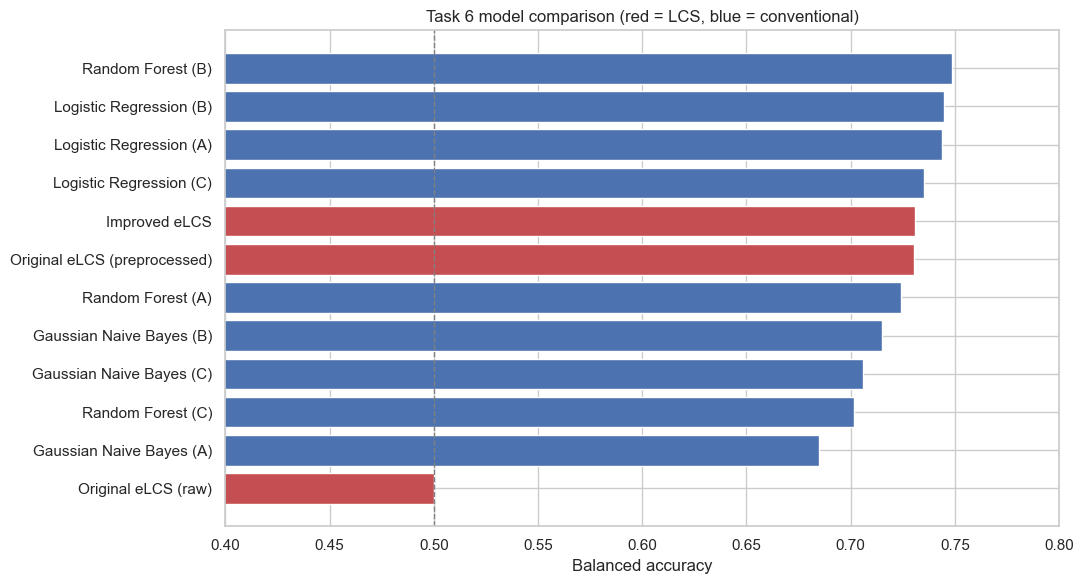

In [10]:
plt.figure(figsize=(11, 6))

colours = [
    "#c44e52" if "eLCS" in name else "#4c72b0"
    for name in comparison.index
]

plt.barh(
    range(len(comparison)),
    comparison["balanced_accuracy"],
    color=colours,
)

plt.yticks(range(len(comparison)), comparison.index)
plt.gca().invert_yaxis()
plt.xlabel("Balanced accuracy")
plt.title("Task 6 model comparison (red = LCS, blue = conventional)")
plt.axvline(0.5, color="grey", linestyle="--", linewidth=1)
plt.xlim(0.4, 0.8)
plt.tight_layout()
plt.show()

### Recall against precision

Balanced accuracy alone hides an important difference between the models. In a
screening context the two error types have very different consequences: a false
negative is a missed case, while a false positive leads to an unnecessary
follow-up test. Plotting recall against precision shows what each model trades
away.

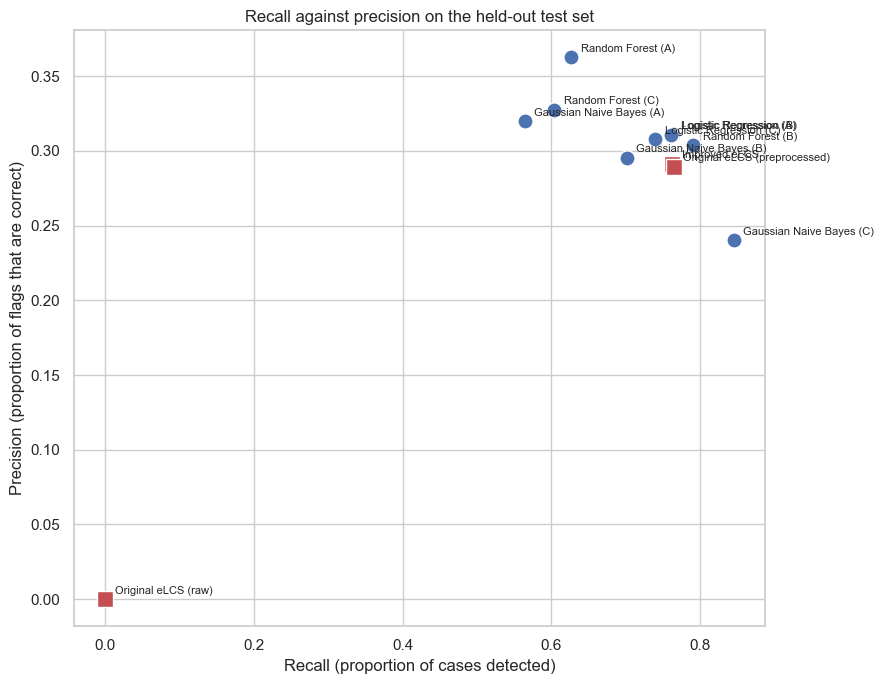

In [11]:
plt.figure(figsize=(9, 7))

for name in comparison.index:
    is_lcs = "eLCS" in name
    plt.scatter(
        comparison.loc[name, "recall"],
        comparison.loc[name, "precision"],
        s=120,
        color="#c44e52" if is_lcs else "#4c72b0",
        marker="s" if is_lcs else "o",
        edgecolor="white",
        zorder=3,
    )
    plt.annotate(
        name,
        (comparison.loc[name, "recall"], comparison.loc[name, "precision"]),
        textcoords="offset points",
        xytext=(7, 4),
        fontsize=8,
    )

plt.xlabel("Recall (proportion of cases detected)")
plt.ylabel("Precision (proportion of flags that are correct)")
plt.title("Recall against precision on the held-out test set")
plt.tight_layout()
plt.show()

## 6. Statistical comparison

McNemar's test is applied to every pair of models. Because all twelve models
were evaluated on the same 50,736 records, the test compares them record by
record: it counts the cases where one model is correct and the other is not,
and asks whether that disagreement is one-sided enough to be attributable to a
real difference rather than to chance.

The Holm-Bonferroni correction is applied because 66 pairs are tested, and
without correction roughly three of them would be expected to appear
significant by chance alone.

In [12]:
all_predictions, y_test_saved = load_predictions(results_dir=results_dir)

print("Models loaded for testing:", len(all_predictions))

mcnemar_all = pairwise_mcnemar(all_predictions, y_test_saved)
mcnemar_all.to_csv(results_dir / "full_comparison_mcnemar.csv", index=False)

print(f"Pairs tested: {len(mcnemar_all)}")
print(f"Significant after Holm correction: {int(mcnemar_all['significant'].sum())}")

Models loaded for testing: 12
Pairs tested: 66
Significant after Holm correction: 61


In [13]:
# Comparisons involving the improved LCS, which are the ones Task 4 and
# Task 6 ask about directly
improved_rows = mcnemar_all[
    (mcnemar_all["model_a"].str.contains("Improved"))
    | (mcnemar_all["model_b"].str.contains("Improved"))
].copy()

display(
    improved_rows[[
        "model_a", "model_b", "a_right_b_wrong",
        "b_right_a_wrong", "p_value", "p_holm", "significant",
    ]].round(4)
)

,model_a,model_b,a_right_b_wrong,b_right_a_wrong,p_value,p_holm,significant
9,Gaussian Naive Bayes C,Improved eLCS,2263,7464,0.0000,0.0000,True
14,Improved eLCS,Random Forest A,1648,6010,0.0000,0.0000,True
15,Improved eLCS,Original eLCS raw,5387,13105,0.0000,0.0000,True
29,Gaussian Naive Bayes A,Improved eLCS,5862,2632,0.0000,0.0000,True
31,Improved eLCS,Random Forest C,3470,6690,0.0000,0.0000,True
45,Improved eLCS,Logistic Regression B,1840,3019,0.0000,0.0000,True
46,Improved eLCS,Logistic Regression A,1859,3030,0.0000,0.0000,True
48,Improved eLCS,Logistic Regression C,2619,3814,0.0000,0.0000,True
53,Gaussian Naive Bayes B,Improved eLCS,3692,2829,0.0000,0.0000,True
56,Improved eLCS,Random Forest B,2319,2824,0.0000,0.0000,True


## 7. Export the rule population for Task 7

The improved model's final rule population is exported so that Task 7 can
discuss specific classifiers. Each rule records the attributes it specifies,
the conditions on those attributes, the class it predicts, and its accuracy,
fitness and numerosity.

In [14]:
rules_path = results_dir / "improved_elcs_rules.csv"

fitted_models["Improved eLCS"].export_final_rule_population(
    headerNames=np.array(X_test.columns),
    className="Diabetes_binary",
    filename=str(rules_path),
    DCAL=True,
)

rules = pd.read_csv(rules_path)

print(f"Exported {len(rules)} rules to {rules_path.name}")
print("\nMost accurate rules with wide coverage:")

display(
    rules[rules["Match Count"] > 100]
    .sort_values(["Accuracy", "Numerosity"], ascending=False)
    .head(10)
    [[
        "Specified Attribute Names", "Specified Values",
        "Diabetes_binary", "Accuracy", "Numerosity", "Match Count",
    ]]
)

Exported 1821 rules to improved_elcs_rules.csv

Most accurate rules with wide coverage:


,Specified Attribute Names,Specified Values,Diabetes_binary,Accuracy,Numerosity,Match Count
814,"Smoker, Stroke, Veggies, HvyAlcoholConsump, Ge...","0, 0, 1, 0, [0.4670686734677377,1.94], 0, [0.2...",0,1.000000,1,114
883,"Smoker, Veggies, HvyAlcoholConsump, GenHlth, D...","0, 1, 0, [0.4670686734677377,1.94], 0, [0.2800...",0,1.000000,1,103
812,"Smoker, Stroke, HvyAlcoholConsump, GenHlth, Di...","0, 0, 0, [0.4670686734677377,1.94], 0, [0.2800...",0,0.985075,1,134
776,"HighChol, Smoker, HvyAlcoholConsump, GenHlth, ...","0, 0, 0, [0.05999999999999994,1.94], 0, [1.88,...",0,0.982456,1,114
326,"HighBP, HighChol, Smoker, HeartDiseaseorAttack...","0, 0, 0, 0, 1, 0, [-0.41999999999999993,2.5], ...",0,0.961905,1,105
604,"HighBP, HighChol, Fruits, AnyHealthcare, GenHl...","0, 0, 0, 1, [-0.41999999999999993,2.5], 0",0,0.960396,1,101
675,"HighBP, HighChol, BMI, Smoker, Stroke, HeartDi...","0, 0, [-2.950000000000003,42.95], 0, 0, 0, 0, ...",0,0.957746,1,213
350,"HighChol, CholCheck, PhysActivity, GenHlth, Me...","0, 1, 1, [-0.3600000000000001,2.36000000000000...",0,0.946203,1,316
882,"HighChol, Smoker, Stroke, HvyAlcoholConsump, G...","0, 0, 0, 0, [0.05999999999999994,1.94], 0",0,0.939189,1,148
342,"HighBP, HighChol, Smoker, HeartDiseaseorAttack...","0, 0, 0, 0, 1, 0, [-0.41999999999999993,2.5], ...",0,0.938503,1,374


## 8. Findings

The original eLCS model on the minimally processed dataset achieved a balanced accuracy of 0.5000 and failed to identify any positive diabetes cases. Applying the original eLCS to the balanced preprocessed training data increased balanced accuracy to 0.7302. The improved eLCS achieved a balanced accuracy of 0.7309. Therefore, nearly all of the improvement over the original baseline came from balancing and preprocessing the training data, while explicit attribute configuration and hyperparameter selection produced only a small additional gain of approximately 0.0008.

The improved eLCS did not achieve the highest predictive performance overall. Random Forest B produced the highest balanced accuracy at 0.7486, followed by Logistic Regression B at 0.7447. Nevertheless, the improved eLCS achieved a competitive balanced accuracy of 0.7309 and provides an interpretability advantage because its learned rules can be inspected and related to combinations of patient characteristics.

McNemar’s test found a clear difference between the improved eLCS and the original model on the minimally processed dataset. However, the difference between the improved eLCS and the original eLCS on the preprocessed dataset was not statistically significant after Holm correction (p_holm = 0.0511). This supports the conclusion that balancing and preprocessing were responsible for most of the performance gain, rather than the changes to the eLCS configuration alone.

The precision–recall results demonstrate an important screening trade-off. The improved eLCS achieved recall of 0.7621 but precision of 0.2913. It therefore detected most participants with prediabetes or diabetes, but also produced a substantial number of false-positive predictions. For a preliminary screening tool, higher recall may be preferable because missed positive cases can prevent at-risk individuals from receiving further assessment. The model should not, however, be treated as a diagnostic system because a positive prediction would require clinical confirmation.

Neither the original nor improved eLCS evaluation left test records unclassified. Consequently, the reported recall values were not reduced by unclassified records being converted into negative predictions.